In [40]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

# Klasifikasi Penyakit Jantung dengan SVM

Notebook ini dipakai khusus untuk tugas SVM pada data Cleveland. Fokusnya bukan membandingkan banyak model, tapi memastikan alur SVM jelas dari persiapan data sampai evaluasi.

## Alur Singkat

1. Cek struktur dan kualitas data.
2. Lihat distribusi target dan fitur utama.
3. Siapkan preprocessing dalam pipeline.
4. Bandingkan beberapa kernel SVM.
5. Lakukan tuning hyperparameter dan evaluasi final.

In [41]:
def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'dataset' / 'heart_cleveland.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate dataset/heart_cleveland.csv from the current working directory.')


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'dataset' / 'heart_cleveland.csv'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'images'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
df = pd.read_csv(DATA_PATH)
print('Bentuk dataset:', df.shape)

Bentuk dataset: (297, 14)


In [43]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [45]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [46]:
missing_table = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
})
display(missing_table)
print('Baris duplikat:', df.duplicated().sum())

,missing_values,missing_pct,n_unique
age,0,0.0,41
sex,0,0.0,2
cp,0,0.0,4
trestbps,0,0.0,50
chol,0,0.0,152
fbs,0,0.0,2
restecg,0,0.0,3
thalach,0,0.0,91
exang,0,0.0,2
oldpeak,0,0.0,40


Baris duplikat: 0


In [47]:
target_col = 'condition'
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
feature_cols = numeric_features + categorical_features

## Gambaran Target

Sebelum training, kita cek komposisi kelas pada `condition` supaya metrik performa tidak menyesatkan.

## Eksplorasi Fitur Numerik

Bagian ini dipakai untuk melihat pola sebaran tiap fitur numerik dan menandai nilai yang perlu dicermati.

In [48]:
target_counts = df[target_col].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(2)
target_summary = pd.DataFrame({'jumlah': target_counts, 'persentase': target_pct})
display(target_summary)

,jumlah,persentase
condition,,
0,160,53.87
1,137,46.13


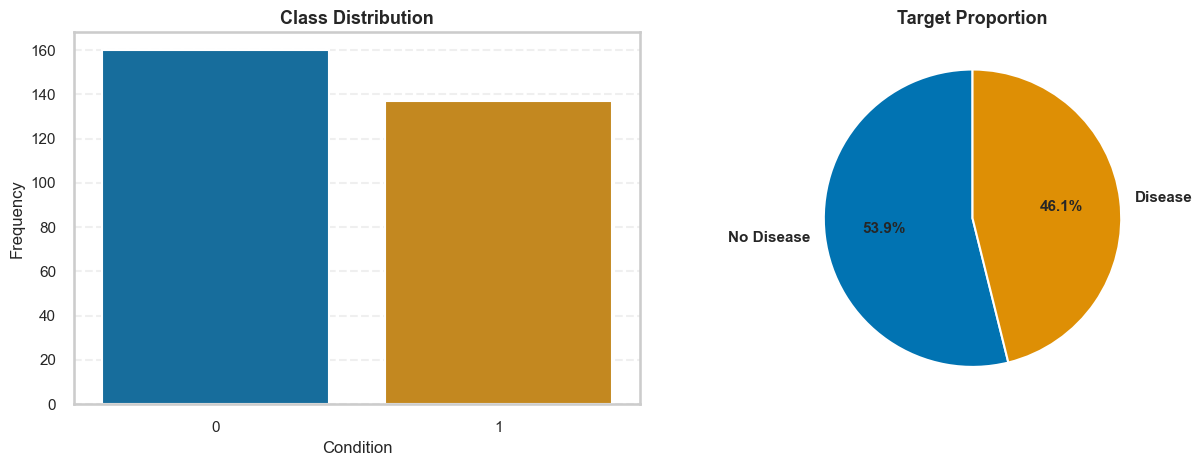

<Figure size 640x480 with 0 Axes>

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].set_facecolor('white')
axes[1].set_facecolor('white')

sns.countplot(data=df, x=target_col, palette=['#0173B2', '#DE8F05'], ax=axes[0])
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Condition', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].tick_params(labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

axes[1].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%', startangle=90,
            colors=['#0173B2', '#DE8F05'], textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Target Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'target_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

plt.tight_layout()

## Fitur Numerik

Visualisasi numerik ini dipakai sebagai konteks sebelum model dilatih.

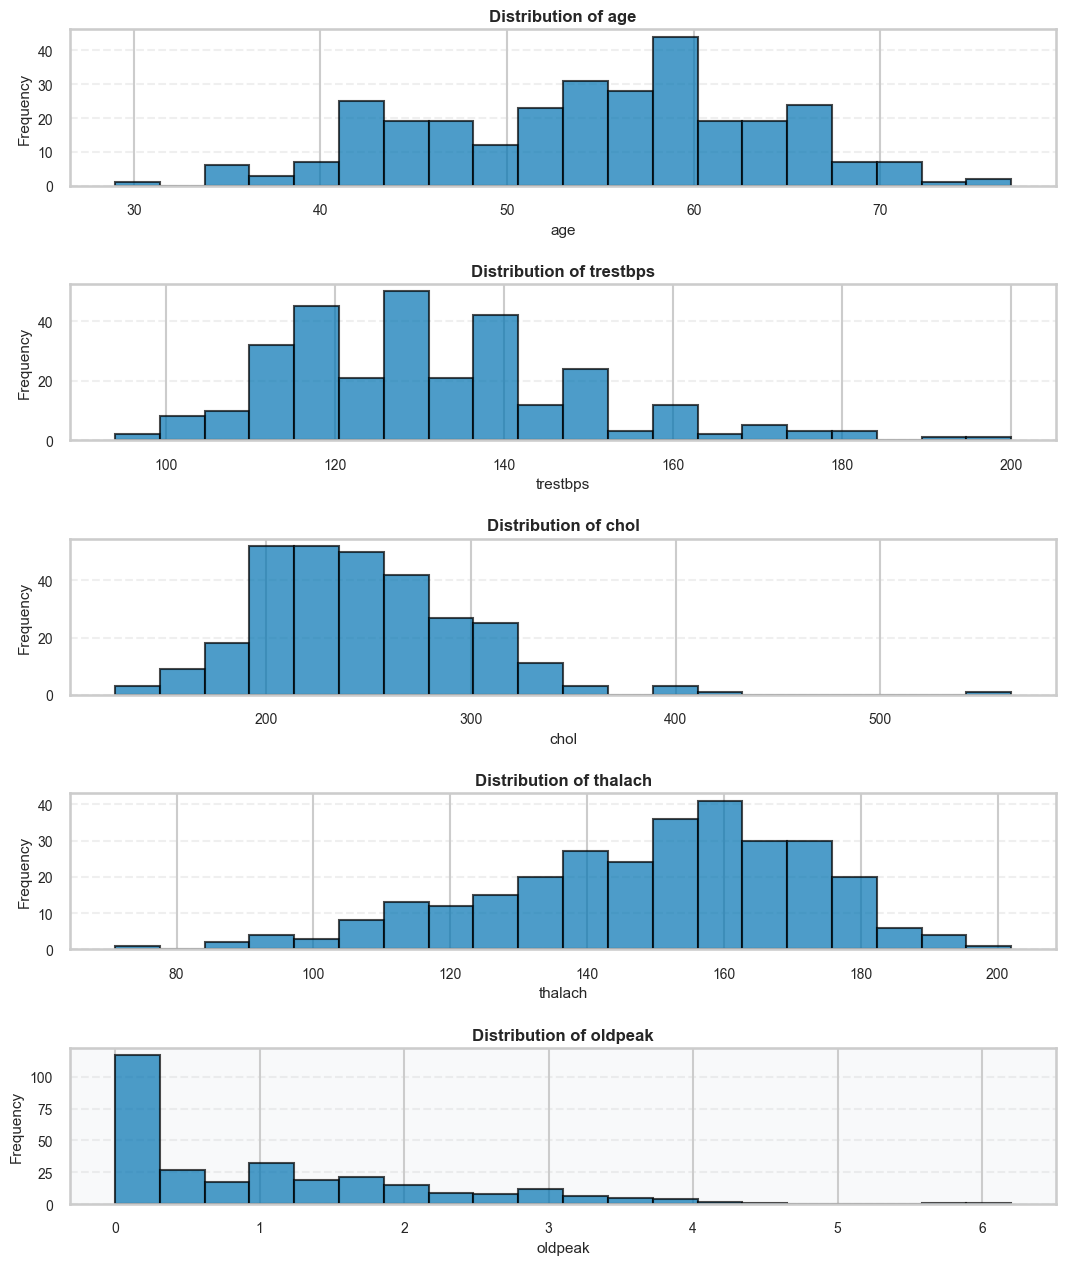

In [50]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(11, 13))
for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col], bins=20, edgecolor='black', alpha=0.7, color='#0173B2', density=False)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].tick_params(labelsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
axes[idx].set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'numeric_distributions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

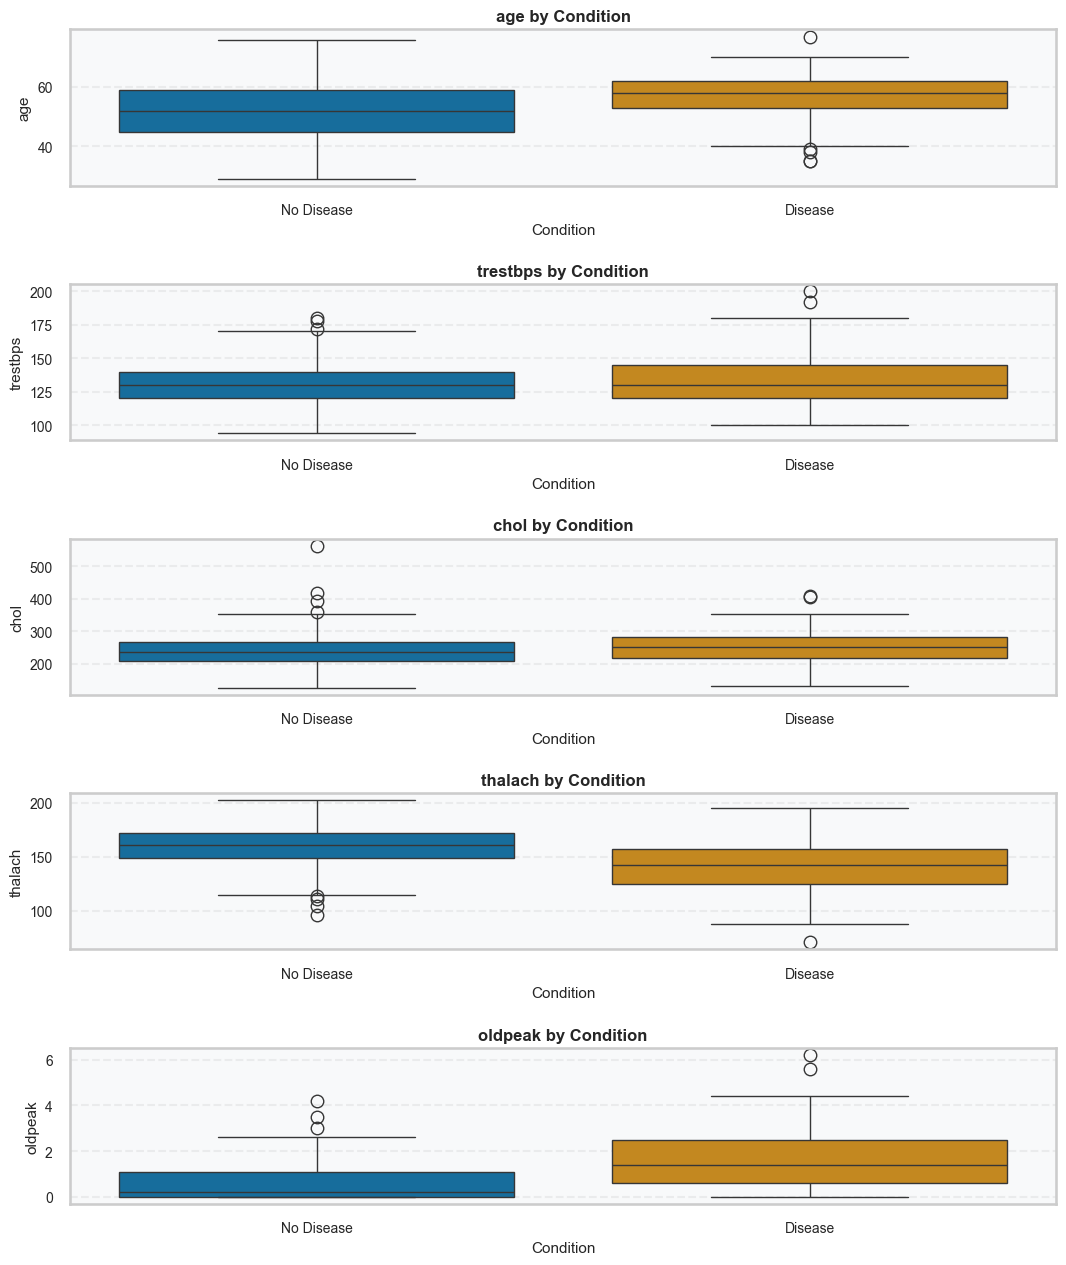

In [51]:
fig, axes = plt.subplots(len(numeric_features), 1, figsize=(11, 13))
for idx, col in enumerate(numeric_features):
    sns.boxplot(data=df, x=target_col, y=col, palette=['#0173B2', '#DE8F05'], ax=axes[idx])
    axes[idx].set_title(f'{col} by Condition', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Condition', fontsize=11)
    axes[idx].set_ylabel(col, fontsize=11)
    axes[idx].set_xticklabels(['No Disease', 'Disease'], fontsize=10)
    axes[idx].tick_params(labelsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'numeric_boxplots.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Fitur Kategorik

Distribusi kategori membantu melihat apakah ada kategori yang terlalu dominan atau terlalu jarang.

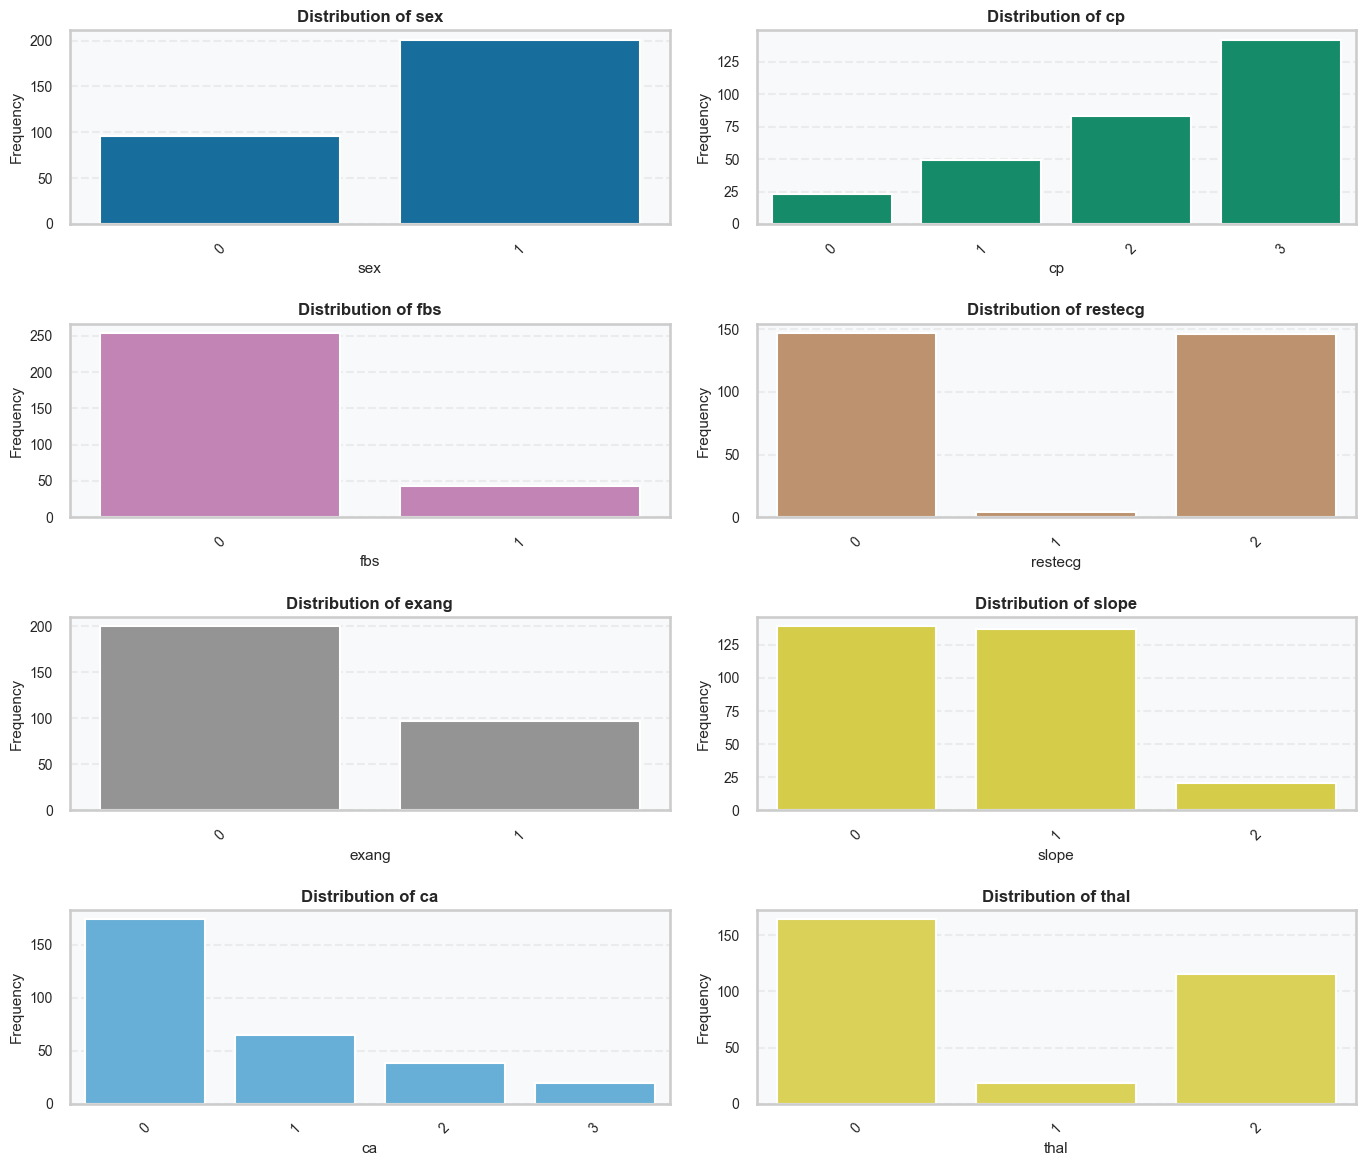

In [52]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
palette = ['#0173B2', '#029E73', '#CC78BC', '#CA9161', '#949494', '#ECE133', '#56B4E9', '#F0E442']

for idx, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[idx], color=palette[idx % len(palette)])
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=10)
    axes[idx].tick_params(axis='y', labelsize=10)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'categorical_distributions.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

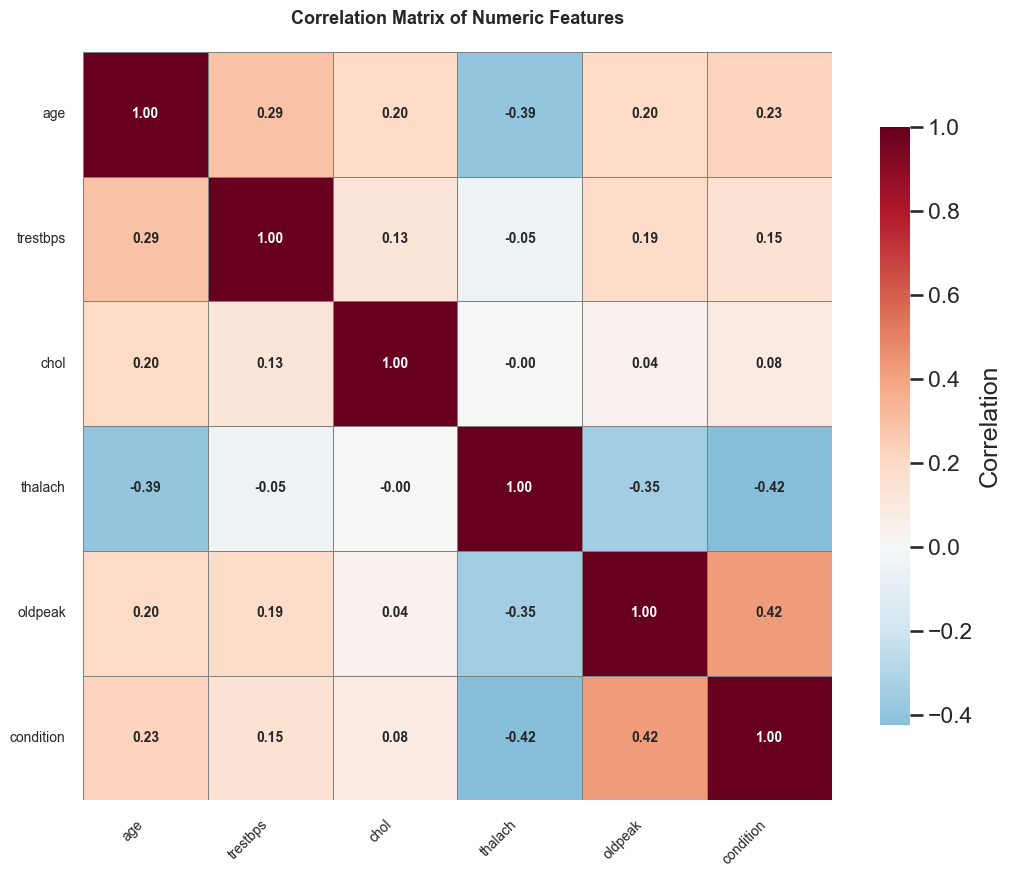

In [53]:
plt.figure(figsize=(11, 9))
corr_matrix = df[numeric_features + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            cbar_kws={'label': 'Correlation', 'shrink': 0.8}, annot_kws={'fontsize': 10, 'weight': 'bold'},
            linewidths=0.5, linecolor='gray')
plt.title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'correlation_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Strategi Pemodelan

Semua langkah preprocessing dimasukkan ke pipeline supaya tidak terjadi data leakage saat cross-validation.

In [54]:
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [55]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features),
])

In [56]:
svm_pipelines = {
    'Linear SVM': Pipeline([('preprocessor', preprocessor), ('model', SVC(kernel='linear', class_weight='balanced'))]),
    'RBF SVM': Pipeline([('preprocessor', preprocessor), ('model', SVC(kernel='rbf', class_weight='balanced'))]),
    'Poly SVM': Pipeline([('preprocessor', preprocessor), ('model', SVC(kernel='poly', class_weight='balanced'))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [57]:
comparison_rows = []
for name, pipeline in svm_pipelines.items():
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    comparison_rows.append({
        'model': name,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy_score(y_test, y_pred),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('test_accuracy', ascending=False)

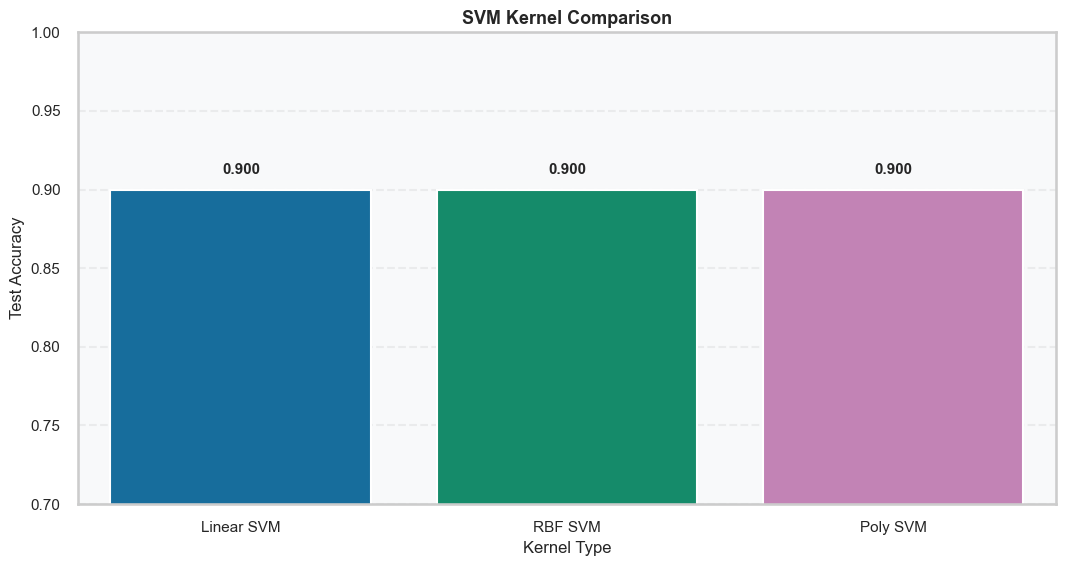

In [58]:
plt.figure(figsize=(11, 6))
palette_kern = ['#0173B2', '#029E73', '#CC78BC']
sns.barplot(data=comparison_df, x='model', y='test_accuracy', palette=palette_kern)
plt.ylim(0.7, 1.0)
plt.title('SVM Kernel Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('Kernel Type', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#F8F9FA')

for i, v in enumerate(comparison_df['test_accuracy'].values):
    plt.text(i, v + 0.008, f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'svm_kernel_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [59]:
display(comparison_df)

,model,cv_mean,cv_std,test_accuracy
0,Linear SVM,0.814805,0.057297,0.9
1,RBF SVM,0.797784,0.037173,0.9
2,Poly SVM,0.780674,0.020475,0.9


## Tuning Model

Setelah perbandingan kernel, kita lanjutkan grid search untuk mencari konfigurasi SVM yang paling konsisten.

In [60]:
param_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10, 100],
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto', 0.1, 0.01],
    },
    {
        'model__kernel': ['poly'],
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto', 0.1],
        'model__degree': [2, 3, 4],
    },
]

In [61]:
tuned_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(class_weight='balanced'))
])

grid_search = GridSearchCV(
    tuned_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    refit=True,
)

In [66]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)

print('Parameter terbaik:', grid_search.best_params_)
print('Akurasi validasi silang terbaik:', round(grid_search.best_score_, 4))
print('Akurasi data uji:', round(accuracy_score(y_test, best_predictions), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, best_model.decision_function(X_test)), 4))
print()
print(classification_report(y_test, best_predictions, target_names=['Tidak Ada Penyakit', 'Ada Penyakit']))

Parameter terbaik: {'model__C': 1, 'model__kernel': 'linear'}
Akurasi validasi silang terbaik: 0.8148
Akurasi data uji: 0.9
ROC-AUC: 0.9688

                    precision    recall  f1-score   support

Tidak Ada Penyakit       0.84      1.00      0.91        32
      Ada Penyakit       1.00      0.79      0.88        28

          accuracy                           0.90        60
         macro avg       0.92      0.89      0.90        60
      weighted avg       0.92      0.90      0.90        60



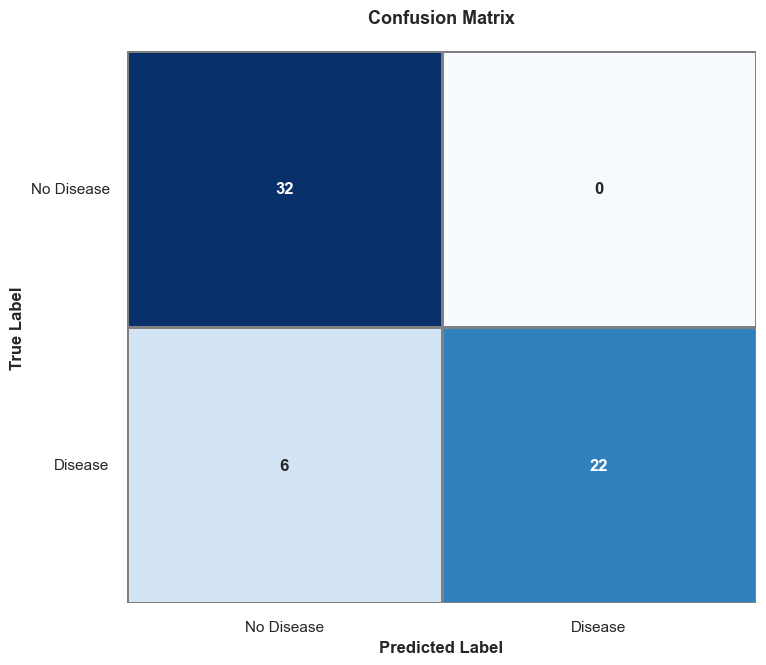

In [63]:
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'],
            annot_kws={'fontsize': 12, 'weight': 'bold'}, linewidths=2, linecolor='gray')
plt.title('Confusion Matrix', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11, rotation=0)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

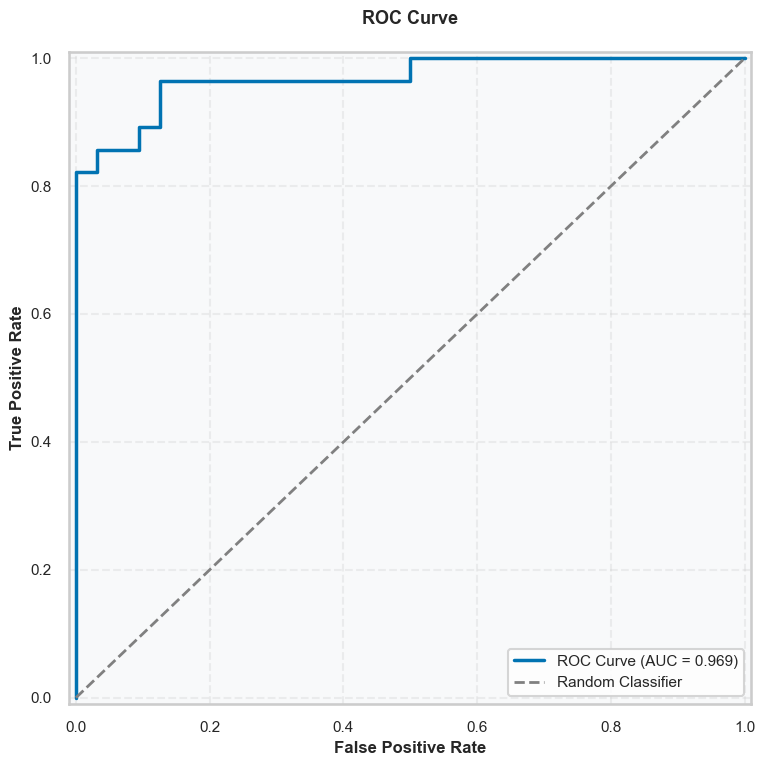

In [64]:
y_scores = best_model.decision_function(X_test)
auc_score = roc_auc_score(y_test, y_scores)

from sklearn.metrics import roc_curve as roc_curve_func
fpr, tpr, _ = roc_curve_func(y_test, y_scores)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='#0173B2', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve', fontsize=13, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='lower right')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#F8F9FA')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curve.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Kesimpulan

Eksperimen SVM pada dataset Cleveland menghasilkan model terbaik dengan **kernel linear** dan parameter **C = 1**.

### Ringkasan Hasil Akhir
- Akurasi validasi silang terbaik: **0.8148**
- Akurasi pada data uji: **0.90**
- ROC-AUC pada data uji: **0.9688**

### Interpretasi Output Klasifikasi
- Kelas **Tidak Ada Penyakit**: precision **0.84**, recall **1.00**, F1-score **0.91**
- Kelas **Ada Penyakit**: precision **1.00**, recall **0.79**, F1-score **0.88**
- Akurasi total: **0.90** (60 sampel uji)

Secara umum, model sudah baik untuk membedakan dua kelas. Model sangat kuat dalam menangkap kelas *Tidak Ada Penyakit* (recall tinggi), namun masih ada sebagian kasus *Ada Penyakit* yang terlewat (recall 0.79), sehingga ini bisa jadi fokus perbaikan lanjutan.